# Projekt: Analiza Tekstu i Redukcja Wymiarów (Zadania 1 i 2)
Ten notebook zawiera kompletne rozwiązanie dla Zadania 1 (Wektoryzacja tekstu za pomocą `sentence-transformers`) oraz Zadania 2 (Redukcja wymiarów przy użyciu `PCA` i `t-SNE` wraz z wizualizacją).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Wszystkie biblioteki zaimportowane pomyślnie!")

Wszystkie biblioteki zaimportowane pomyślnie!


## Krok 1: Wektoryzacja tekstu (Zadanie 1)
Wczytujemy dane piosenek z lokalizacji `data/processed/songs.csv` i generujemy embeddingi tekstowe dla kolumny `lyrics` przy użyciu modelu `all-MiniLM-L6-v2`.

In [2]:
csv_path = "data/processed/songs.csv"
embeddings_out = "data/processed/embeddings.npy"
labels_out = "data/processed/labels.npy"
outputs_dir = "outputs"

# Upewniamy się, że katalog na wykresy istnieje
os.makedirs(outputs_dir, exist_ok=True)

# Sprawdzenie i awaryjne wczytanie pliku
if not os.path.exists(csv_path):
    if os.path.exists("songs.csv"):
        os.makedirs("data/processed", exist_ok=True)
        import shutil
        shutil.copy("songs.csv", csv_path)
    else:
        raise FileNotFoundError(f"Nie znaleziono pliku {csv_path}!")

print(f"Wczytywanie danych z {csv_path}...")
df = pd.read_csv(csv_path)
print(f"Liczba wierszy: {len(df)}")

print("Inicjalizacja modelu sentence-transformers (all-MiniLM-L6-v2)...")
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Generowanie embeddingów dla kolumny df['lyrics']...")
lyrics_list = df["lyrics"].fillna("").tolist()
embeddings = model.encode(lyrics_list, show_progress_bar=True)

print(f"Kształt wygenerowanej macierzy: {embeddings.shape}")

# Zapis macierzy do plików .npy
np.save(embeddings_out, embeddings)
print(f"Zapisano embeddingi do: {embeddings_out}")

if "mood_label" in df.columns:
    labels = df["mood_label"].dropna().to_numpy()
    np.save(labels_out, labels)
    print(f"Zapisano etykiety nastrojów do: {labels_out}")

Wczytywanie danych z data/processed/songs.csv...
Liczba wierszy: 160
Inicjalizacja modelu sentence-transformers (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\Jakub Krzoska\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Jakub Krzoska\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generowanie embeddingów dla kolumny df['lyrics']...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Kształt wygenerowanej macierzy: (160, 384)
Zapisano embeddingi do: data/processed/embeddings.npy
Zapisano etykiety nastrojów do: data/processed/labels.npy


## Krok 2: Redukcja wymiarów & Wizualizacja (Zadanie 2)
Dokonujemy redukcji wymiarów za pomocą algorytmów **PCA** oraz **t-SNE** do przestrzeni dwuwymiarowej (2D), a następnie generujemy wymagane wykresy.

Obliczanie PCA -> 2D...
Obliczanie t-SNE -> 2D...


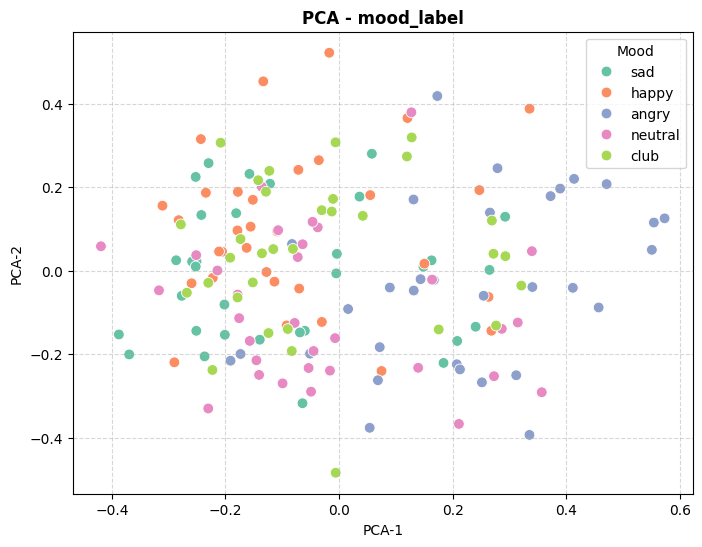

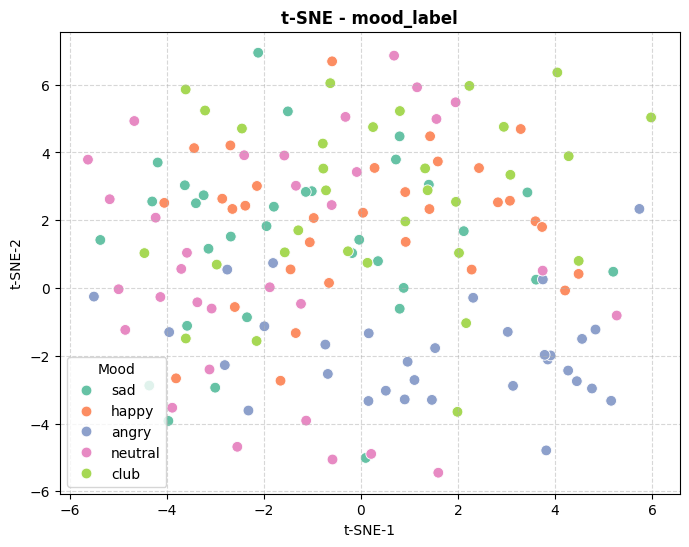

Wykresy zostały wygenerowane i zapisane w folderze 'outputs/'!


In [4]:
# 1. PCA do 2D
print("Obliczanie PCA -> 2D...")
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(embeddings)

# 2. t-SNE do 2D
print("Obliczanie t-SNE -> 2D...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(embeddings)

# Przygotowanie danych do wykresu
df_viz = pd.DataFrame({
    "PCA-1": pca_results[:, 0],
    "PCA-2": pca_results[:, 1],
    "t-SNE-1": tsne_results[:, 0],
    "t-SNE-2": tsne_results[:, 1],
    "Mood": df["mood_label"]
})

# Definicja mapy kolorów
moods = ["sad", "happy", "angry", "neutral", "club"]
palette = sns.color_palette("Set2", len(moods))
color_map = dict(zip(moods, palette))

# Generowanie i zapisywanie pojedynczego wykresu PCA
fig_pca, ax_pca = plt.subplots(figsize=(8, 6))
sns.scatterplot(x="PCA-1", y="PCA-2", hue="Mood", data=df_viz, palette=color_map, ax=ax_pca, s=60)
ax_pca.set_title("PCA - mood_label", fontsize=12, fontweight="bold")
ax_pca.grid(True, linestyle="--", alpha=0.5)
pca_img_path = os.path.join(outputs_dir, "pca_mood.png")
plt.savefig(pca_img_path, dpi=300)
plt.show()

# Generowanie i zapisywanie pojedynczego wykresu t-SNE
fig_tsne, ax_tsne = plt.subplots(figsize=(8, 6))
sns.scatterplot(x="t-SNE-1", y="t-SNE-2", hue="Mood", data=df_viz, palette=color_map, ax=ax_tsne, s=60)
ax_tsne.set_title("t-SNE - mood_label", fontsize=12, fontweight="bold")
ax_tsne.grid(True, linestyle="--", alpha=0.5)
tsne_img_path = os.path.join(outputs_dir, "tsne_mood.png")
plt.savefig(tsne_img_path, dpi=300)
plt.show()

print("Wykresy zostały wygenerowane i zapisane w folderze 'outputs/'!")